# M-Detector Debugging and Tuning Notebook
## 0. Setup and Imports

In [1]:
# %%
import os
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
import k3d
import h5py
from tqdm.notebook import tqdm # Use tqdm.notebook for better notebook integration
from pyquaternion import Quaternion
import logging
from typing import Dict, List, Optional, Tuple, Any

# --- Add Project Root to sys.path ---
# Adjust this path if your notebook is located elsewhere relative to the project root
NOTEBOOK_DIR = os.path.abspath('') 
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR) 
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added project root to sys.path: {PROJECT_ROOT}")

# --- Import Custom Modules (after adding project root) ---
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import Box as NuScenesDataClassesBox

# Core M-Detector components
from src.core.m_detector.base import MDetector
from src.core.depth_image import DepthImage
from src.core.constants import OcclusionResult, POINT_LABEL_DTYPE
from src.core.debug_collector import PointDebugCollector

# Data utilities
from src.data_utils.nuscenes_helper import get_scene_sweep_data_sequence, get_lidar_sweep_data
from src.utils.transformations import transform_points_numpy
from src.utils.validation_utils import get_gt_dynamic_points_for_sweep # For GT matching
# Import from notebook_helpers.py
from src.utils.notebook_helpers import (
    load_gt_labels_for_sweep_from_hdf5, 
    load_mdet_results_for_sweep_from_hdf5,
    create_k3d_plot_with_points
)

from src.utils.debug_helpers import debug_point_m_detector_logic, get_misclassified_points 

Added project root to sys.path: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python


In [2]:

# --- Configure Logging for M-Detector ---
# Get the root logger for M-Detector if specific modules have their own
# For simplicity, let's configure logging for the 'src' module or specific M-Detector modules.
# Example: Configure logging for the MDetector class itself
mdetector_logger = logging.getLogger('src.core.m_detector.base') # Or 'src.core.m_detector' for the whole module
mdetector_logger.setLevel(logging.DEBUG)
processing_logger = logging.getLogger('src.core.m_detector.processing')
processing_logger.setLevel(logging.DEBUG)
# map_consistency_logger = logging.getLogger('src.core.m_detector.map_consistency')
# map_consistency_logger.setLevel(logging.DEBUG)

print("Logging configured.")

# %%
# --- Load Configuration ---
try:
    config_path = os.path.join(PROJECT_ROOT, 'config/m_detector_config.yaml')
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    print(f"Configuration loaded successfully from: {config_path}")
except FileNotFoundError:
    print(f"ERROR: Config file not found at {config_path}. Please check the path.")
    config = {} 
except Exception as e:
    print(f"Error loading config: {e}")
    config = {}

# --- Initialize NuScenes ---
nusc = None
if 'nuscenes' in config and config.get('nuscenes', {}).get('dataroot'):
    try:
        nusc = NuScenes(
            version=config['nuscenes']['version'],
            dataroot=config['nuscenes']['dataroot'],
            verbose=config.get('nuscenes', {}).get('verbose_init', False)
        )
        print(f"NuScenes SDK initialized (Version: {config['nuscenes']['version']}).")
    except Exception as e:
        print(f"Error initializing NuScenes SDK: {e}")
else:
    print("ERROR: NuScenes 'dataroot' or 'version' missing in config. Cannot initialize NuScenes SDK.")

# --- Define Paths for GT Labels and M-Detector Outputs (HDF5) ---
# These should ideally come from your config or be set explicitly here
GT_LABELS_HDF5_DIR = config.get('nuscenes', {}).get('label_path', os.path.join(PROJECT_ROOT, 'data/gt_labels_hdf5'))
MDET_RESULTS_HDF5_DIR = config.get('mdetector_output', {}).get('save_path', os.path.join(PROJECT_ROOT, 'output/mdet_results_hdf5'))

print(f"GT Labels HDF5 Directory: {GT_LABELS_HDF5_DIR}")
print(f"M-Detector Results HDF5 Directory: {MDET_RESULTS_HDF5_DIR}")

# --- Scene and Sweep Selection ---
TARGET_SCENE_NAME = 'scene-0103' 

SKIP_SWEEPS = 40
MAX_SWEEPS = 20
TARGET_SWEEP_INDEX_IN_SCENE = 10 # SKIP_SWEEPS + TARGET_SWEEP_INDEX_IN_SCENE = actual sweep index

Logging configured.
Configuration loaded successfully from: /home/drugge/Unsupervised-Moving-Point-Detection/m_detector_python/config/m_detector_config.yaml
NuScenes SDK initialized (Version: v1.0-mini).
GT Labels HDF5 Directory: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated
M-Detector Results HDF5 Directory: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/m_detector_output


In [3]:
# %% Cell 2: Data Parameters & M-Detector Instantiation

# --- Scene and Sweep Selection ---
TARGET_SCENE_NAME = 'scene-0103'  # Example scene
SKIP_SWEEPS_FROM_START_OF_SCENE = 40    # How many sweeps to skip from the beginning of the scene
MAX_SWEEPS_TO_CONSIDER_IN_SEQUENCE = 20 # Max sweeps to load into scene_sweeps_full_sequence after skipping
# Index of the specific sweep we want to *target* for detailed debugging *within* the MAX_SWEEPS_TO_CONSIDER_IN_SEQUENCE
TARGET_SWEEP_IDX_IN_CONSIDERED_SEQUENCE = 10 

target_scene_rec = None
scene_sweeps_full_sequence = [] # This will hold the subset of sweeps we are working with

if nusc:
    for scene in nusc.scene:
        if scene['name'] == TARGET_SCENE_NAME:
            target_scene_rec = scene
            break
    
    if target_scene_rec:
        print(f"Target Scene: '{target_scene_rec['name']}' (Token: {target_scene_rec['token']})")
        
        # Get all sweeps for the scene first
        all_sweeps_in_scene_chronological = list(get_scene_sweep_data_sequence(nusc, target_scene_rec['token']))
        
        # Apply skipping and max consideration
        start_index_for_sequence = SKIP_SWEEPS_FROM_START_OF_SCENE
        end_index_for_sequence = SKIP_SWEEPS_FROM_START_OF_SCENE + MAX_SWEEPS_TO_CONSIDER_IN_SEQUENCE
        
        scene_sweeps_full_sequence = all_sweeps_in_scene_chronological[start_index_for_sequence:end_index_for_sequence]
        
        if not scene_sweeps_full_sequence:
            print(f"ERROR: No sweeps available for scene '{TARGET_SCENE_NAME}' after applying SKIP ({SKIP_SWEEPS_FROM_START_OF_SCENE}) and MAX ({MAX_SWEEPS_TO_CONSIDER_IN_SEQUENCE}).")
            TARGET_LIDAR_SD_TOKEN = None
            TARGET_SWEEP_DATA_DICT = None
        elif 0 <= TARGET_SWEEP_IDX_IN_CONSIDERED_SEQUENCE < len(scene_sweeps_full_sequence):
            TARGET_SWEEP_DATA_DICT = scene_sweeps_full_sequence[TARGET_SWEEP_IDX_IN_CONSIDERED_SEQUENCE]
            TARGET_LIDAR_SD_TOKEN = TARGET_SWEEP_DATA_DICT['lidar_sd_token']
            print(f"Target Sweep for detailed analysis (Index {TARGET_SWEEP_IDX_IN_CONSIDERED_SEQUENCE} in considered sequence):")
            print(f"  Token: {TARGET_LIDAR_SD_TOKEN[:8]}..., Timestamp: {TARGET_SWEEP_DATA_DICT['timestamp']}")
        else:
            print(f"ERROR: TARGET_SWEEP_IDX_IN_CONSIDERED_SEQUENCE ({TARGET_SWEEP_IDX_IN_CONSIDERED_SEQUENCE}) is out of bounds for the considered sequence (0-{len(scene_sweeps_full_sequence)-1}).")
            TARGET_LIDAR_SD_TOKEN = None
            TARGET_SWEEP_DATA_DICT = None
            
    else:
        print(f"ERROR: Scene '{TARGET_SCENE_NAME}' not found.")
        TARGET_LIDAR_SD_TOKEN = None
        TARGET_SWEEP_DATA_DICT = None
else:
    print("NuScenes SDK (nusc) not initialized. Cannot select scene/sweep.")
    TARGET_LIDAR_SD_TOKEN = None
    TARGET_SWEEP_DATA_DICT = None

# --- Define Paths for GT Labels (HDF5) ---
# Ensure these are correctly defined, e.g., from config loaded in Cell 1
GT_LABELS_HDF5_DIR = config.get('nuscenes', {}).get('label_path', os.path.join(PROJECT_ROOT, 'data/gt_labels_hdf5'))
print(f"GT Labels HDF5 Directory: {GT_LABELS_HDF5_DIR}")

# --- Instantiate M-Detector ---
detector = None
if config and nusc:
    # --- Configuration Override for Debugging (Optional) ---
    # config['map_consistency_check']['enabled'] = False
    # config['event_tests']['test1_N_depth_images'] = 3 # Example override from your previous debugging
    
    detector = MDetector(config)
    print("M-Detector instantiated.")
else:
    print("M-Detector or NuScenes not initialized. Cannot proceed with M-Detector instantiation.")

# Initialize variables that will be set in the next cell
processed_target_di: Optional[DepthImage] = None
idx_of_processed_target_di: Optional[int] = None

Target Scene: 'scene-0103' (Token: fcbccedd61424f1b85dcbf8f897f9754)
Target Sweep for detailed analysis (Index 10 in considered sequence):
  Token: 9181fe90..., Timestamp: 1533151606048630
GT Labels HDF5 Directory: /home/drugge/staff-umbrella/TeamHolgerResearch/drugge/nuscenes_labels_interpolated
M-Detector instantiated.


In [4]:
# %% Cell 3: M-Detector Library Priming & Target DI Preparation

if detector and target_scene_rec and scene_sweeps_full_sequence and TARGET_LIDAR_SD_TOKEN:
    print(f"\nProcessing sweeps for scene '{target_scene_rec['name']}' to prime M-Detector library...")
    
    detector.reset_scene_state() # Reset for the new scene
    
    # Iterate through the selected sequence of sweeps
    # (scene_sweeps_full_sequence was defined and populated in Cell 2)
    for i, sweep_data in enumerate(tqdm(scene_sweeps_full_sequence, desc="Feeding Sweeps to M-Detector")):
        added_di = detector.add_sweep_and_create_depth_image(
            points_lidar_frame=sweep_data['points_sensor_frame'],
            T_global_lidar=sweep_data['T_global_lidar'],
            lidar_timestamp=sweep_data['timestamp'],
            lidar_sd_token=sweep_data['lidar_sd_token']
        )
        
        # If this is the target sweep, we just add it and break.
        # It will be processed manually in a later cell.
        if sweep_data['lidar_sd_token'] == TARGET_LIDAR_SD_TOKEN:
            processed_target_di = added_di
            try:
                # Find its index in the library's current state
                idx_of_processed_target_di = detector.depth_image_library.get_all_images().index(processed_target_di)
            except ValueError:
                print(f"ERROR: Target DI (Token: {TARGET_LIDAR_SD_TOKEN}) was added but not found in library. This is unexpected.")
                idx_of_processed_target_di = -1 # Mark as error
            
            if idx_of_processed_target_di != -1:
                print(f"\nTarget sweep {TARGET_LIDAR_SD_TOKEN[:8]}... added to M-Detector library at index {idx_of_processed_target_di}.")
                print(f"  It is now ready for manual processing and inspection.")
            break # Stop feeding sweeps after adding the target sweep
        
        else: # This is a sweep *before* the target sweep
            # Process it causally to build up history for the M-Detector
            if not detector.use_bidirectional: # Assuming causal focus for priming
                # Find the index of the newly added DI (it's the last one in the deque)
                if detector.depth_image_library:
                    # Index in deque: -1 is newest, 0 is oldest. Library length is len().
                    # For _process_causal_di_wrapper, we need index from start of deque.
                    idx_to_process_causal = len(detector.depth_image_library) - 1
                    
                    # Check M-Detector's readiness criteria for causal processing
                    if detector.timestamp_of_last_processed_di is None or \
                       added_di.timestamp > detector.timestamp_of_last_processed_di:
                        if idx_to_process_causal >= detector.min_sweeps_for_processing -1 :
                            # print(f"  Causally processing historical DI at lib_idx {idx_to_process_causal}, TS: {added_di.timestamp}")
                            detector.timestamp_of_last_processed_di = added_di.timestamp # Update before processing
                            detector._process_causal_di_wrapper(idx_to_process_causal)
                        # else:
                            # print(f"  Skipping causal processing for DI TS {added_di.timestamp}, min_sweeps not met ({idx_to_process_causal+1}/{detector.min_sweeps_for_processing}).")
                    # else:
                        # print(f"  Skipping causal processing for DI TS {added_di.timestamp}, not newer than last processed ({detector.timestamp_of_last_processed_di}).")
            # else: Bidirectional priming would be different, perhaps processing windows
            pass # End of non-target sweep processing

    if not processed_target_di:
        print(f"ERROR: Target sweep {TARGET_LIDAR_SD_TOKEN} was not reached or processed correctly in the loop.")
    elif idx_of_processed_target_di == -1:
        print(f"ERROR: Target DI was added but its index in library could not be confirmed.")

else:
    print("Skipping M-Detector library priming: M-Detector not instantiated, scene/sweep not defined, or no sweeps in sequence.")


Processing sweeps for scene 'scene-0103' to prime M-Detector library...


Feeding Sweeps to M-Detector:   0%|          | 0/20 [00:00<?, ?it/s]


Target sweep 9181fe90... added to M-Detector library at index 10.
  It is now ready for manual processing and inspection.


In [5]:
# %% Cell 4: Ground Truth Label Loading for Target DI

gt_indices_dict_for_target: Optional[Dict[str, np.ndarray]] = None

if nusc and TARGET_SWEEP_DATA_DICT and processed_target_di and \
   processed_target_di.original_points_global_coords is not None and \
   target_scene_rec and GT_LABELS_HDF5_DIR and config and detector: # Added detector
    
    print(f"\nLoading Ground Truth labels for the target sweep (Token: {TARGET_LIDAR_SD_TOKEN[:8]}...).")
    
    gt_labels_scene_hdf5_filepath = os.path.join(GT_LABELS_HDF5_DIR, f"gt_point_labels_{target_scene_rec['name']}.h5")
    # Ensure velocity_threshold_gt is correctly fetched from your config
    velocity_threshold_gt = config.get('validation', {}).get('vel_threshold', 1.0) # Fallback

    # Get M-Detector's filtering params from its config
    mdet_min_range = detector.config.get('filtering',{}).get('min_point_range_meters', 1.0)
    mdet_max_range = detector.config.get('filtering',{}).get('max_point_range_meters', 80.0)
    print(f"  Using M-Detector's range filter for GT: min={mdet_min_range:.1f}m, max={mdet_max_range:.1f}m")

    if os.path.exists(gt_labels_scene_hdf5_filepath):
        gt_indices_dict_for_target = get_gt_dynamic_points_for_sweep(
            nusc=nusc, # Pass nusc
            sweep_data_dict=TARGET_SWEEP_DATA_DICT, 
            all_points_global_mdetector=processed_target_di.original_points_global_coords, # M-Detector's points
            gt_labels_scene_hdf5_path=gt_labels_scene_hdf5_filepath,
            velocity_threshold=velocity_threshold_gt,
            mdetector_min_range=mdet_min_range, # Pass M-Detector's range
            mdetector_max_range=mdet_max_range  # Pass M-Detector's range
        )
        
        # Print debug counts from the returned dictionary
        print(f"  [Returned from get_gt_dynamic_points_for_sweep DEBUG]:")
        print(f"    Raw GT HDF5 points for sweep: {gt_indices_dict_for_target.get('debug_gt_hdf5_raw_count', 'N/A')}")
        print(f"    Filtered GT HDF5 points (using MDet range): {gt_indices_dict_for_target.get('debug_gt_hdf5_filtered_count', 'N/A')}")
        print(f"    M-Detector input points for sweep: {gt_indices_dict_for_target.get('debug_mdet_input_count', 'N/A')}")

        if gt_indices_dict_for_target and gt_indices_dict_for_target.get('error_msg') is None:
            print("\nGround Truth INDICES loaded and categorized for the target sweep (index-based).")
            # These counts are now for indices relative to M-Detector's input points
            print(f"  GT Dynamic point INDICES found: {len(gt_indices_dict_for_target.get('gt_dynamic_indices', []))}")
            print(f"  GT Static point INDICES found: {len(gt_indices_dict_for_target.get('gt_static_indices', []))}")
            print(f"  GT Unlabeled point INDICES found: {len(gt_indices_dict_for_target.get('unlabeled_indices', []))}")
        elif gt_indices_dict_for_target:
            print(f"\nFailed to get GT indices for target sweep. Error: {gt_indices_dict_for_target.get('error_msg')}")
        else:
            print(f"\nFunction get_gt_dynamic_points_for_sweep returned None (unexpected).")
    else:
        print(f"ERROR: GT HDF5 file not found: {gt_labels_scene_hdf5_filepath}")
else:
    print("Skipping Ground Truth loading: Prerequisites not met (nusc, target sweep data, processed_target_di, GT path, config, or detector missing).")


Loading Ground Truth labels for the target sweep (Token: 9181fe90...).
  Using M-Detector's range filter for GT: min=1.0m, max=50.0m
  [Returned from get_gt_dynamic_points_for_sweep DEBUG]:
    Raw GT HDF5 points for sweep: 34720
    Filtered GT HDF5 points (using MDet range): 22573
    M-Detector input points for sweep: 22573

Ground Truth INDICES loaded and categorized for the target sweep (index-based).
  GT Dynamic point INDICES found: 802
  GT Static point INDICES found: 112
  GT Unlabeled point INDICES found: 21659


In [6]:
# %% Cell 5: Process Target DI & Identify Misclassifications

misclassified_summary: Optional[Dict[str, List[int]]] = None

if detector and processed_target_di and idx_of_processed_target_di is not None and idx_of_processed_target_di != -1:
    print(f"\nManually processing target DI: TS {processed_target_di.timestamp} (Index in lib: {idx_of_processed_target_di})")
    
    # Initialize and set PointDebugCollector
    # If you want to trace all points, initialize with points_to_trace=None or list(range(num_points))
    # For now, let's initialize it to trace no specific points by default,
    # but it will be active if you later set points_to_trace.
    # The MDetector's process_and_label_di will use it if self.debug_collector is set.
    
    # If you want to trace specific points during *this* processing run:
    # points_to_trace_this_run = [100, 3028] # Example
    # debug_collector = PointDebugCollector(points_to_trace=points_to_trace_this_run)
    # detector.set_debug_collector(debug_collector)
    
    # If you want the collector to be active but decide points later (e.g. for Cell 6):
    debug_collector = PointDebugCollector(points_to_trace=[]) # Active, but no specific points yet
    detector.set_debug_collector(debug_collector)

    # Call the causal processing function directly
    result_dict = detector.process_and_label_di(processed_target_di, idx_of_processed_target_di)
    
    if result_dict.get('success'):
        print(f"Processing successful for target DI.")
        print(f"  Points labeled: {result_dict.get('points_labeled')}")
        label_counts_from_result = result_dict.get('label_counts', {})
        if label_counts_from_result:
            # Construct the dictionary first
            formatted_label_counts = {
                OcclusionResult(k).name: v 
                for k, v in label_counts_from_result.items() 
                # It's safer to assume k might be the integer value from the enum, 
                # so OcclusionResult(k) is good for converting int to enum member.
                # No need for isinstance check if OcclusionResult(k) handles non-member values gracefully (e.g. raises ValueError)
                # or if you are sure k is always a valid enum member or its value.
            }
            print(f"  Label counts: {formatted_label_counts}")
        else:
            print("  Label counts not available in result_dict.")

            
        # Identify misclassifications if GT is available
        if gt_indices_dict_for_target:
            print("\nIdentifying misclassifications...")
            misclassified_summary = get_misclassified_points(processed_target_di, gt_indices_dict_for_target)
            # Example: Print some misclassified points
            if misclassified_summary:
                fp_to_debug = misclassified_summary.get('fp_dynamic', [])
                fn_to_debug = misclassified_summary.get('fn_dynamic', [])
                if fp_to_debug:
                    print(f"  Sample False Positives (Static/Unlabeled -> MDet Dynamic): {fp_to_debug[:min(5, len(fp_to_debug))]}")
                if fn_to_debug:
                    print(f"  Sample False Negatives (Dynamic -> MDet Not Dynamic): {fn_to_debug[:min(5, len(fn_to_debug))]}")
        else:
            print("Ground Truth not available for target sweep, cannot identify misclassifications.")
            
    else:
        print(f"Processing FAILED for target DI. Reason: {result_dict.get('reason')}")
    
    # It's good practice to clear the collector or set points_to_trace for the next specific debug run
    # detector.set_debug_collector(None) # Or set specific points for Cell 6 later
else:
    print("Cannot process target DI: M-Detector not ready, or target DI not identified/found in library.")


Manually processing target DI: TS 1533151606048630 (Index in lib: 10)
Processing successful for target DI.
  Points labeled: 22573
  Label counts: {'OCCLUDING_IMAGE': 424, 'OCCLUDED_BY_IMAGE': 61, 'EMPTY_IN_IMAGE': 287, 'UNDETERMINED': 21801}

Identifying misclassifications...
  Sample False Positives (Static/Unlabeled -> MDet Dynamic): [1930, 4777, 5001, 5201, 5226]
  Sample False Negatives (Dynamic -> MDet Not Dynamic): [3524, 3544, 3545, 3546, 3547]


In [7]:
# %% Cell 6: Deep Dive into Specific Misclassified/Interesting Points

# --- User Input: Select a point index to debug ---
# Example: Choose a point from the misclassified_summary printed in Cell 5
pt_idx_to_debug = 1786 # Default or from misclassified_summary['fp_dynamic'][0] if list is not empty

# Check if misclassified_summary exists and has points
if 'misclassified_summary' in locals() and misclassified_summary and misclassified_summary.get('fp_dynamic'):
    pt_idx_to_debug = misclassified_summary['fp_dynamic'][0] 
    print(f"Selected pt_idx_to_debug from False Positives: {pt_idx_to_debug}")
elif 'misclassified_summary' in locals() and misclassified_summary and misclassified_summary.get('fn_dynamic'):
    pt_idx_to_debug = misclassified_summary['fn_dynamic'][0]
    print(f"No False Positives found. Selected pt_idx_to_debug from False Negatives: {pt_idx_to_debug}")
else:
    pt_idx_to_debug = 100 # Fallback if no misclassifications found or summary not available
    print(f"No misclassifications found or summary not available. Using default pt_idx_to_debug: {pt_idx_to_debug}")

all_gt_labels_array = gt_indices_dict_for_target.get('all_gt_point_labels_filtered')
if all_gt_labels_array is not None and pt_idx_to_debug is not None: # pt_idx_to_debug is P1786's index
    if 0 <= pt_idx_to_debug < len(all_gt_labels_array):
        gt_info_for_P1786 = all_gt_labels_array[pt_idx_to_debug]
        gt_vx = gt_info_for_P1786['velocity_x']
        gt_vy = gt_info_for_P1786['velocity_y']
        gt_speed = np.sqrt(gt_vx**2 + gt_vy**2)
        gt_instance_token = gt_info_for_P1786['instance_token'].decode('utf-8', 'ignore') if gt_info_for_P1786['instance_token'] else "N/A"
        
        print(f"\n  Ground Truth Info for P{pt_idx_to_debug}:")
        print(f"    GT Velocity (vx, vy): ({gt_vx:.2f}, {gt_vy:.2f}) m/s")
        print(f"    GT Speed: {gt_speed:.2f} m/s (Threshold for dynamic: {velocity_threshold_gt} m/s)")
        print(f"    GT Instance Token: {gt_instance_token}")
        if gt_speed < velocity_threshold_gt:
            print(f"    ---> P{pt_idx_to_debug} is GT STATIC (speed {gt_speed:.2f} < {velocity_threshold_gt:.2f})")
        else:
            print(f"    ---> P{pt_idx_to_debug} is GT DYNAMIC (speed {gt_speed:.2f} >= {velocity_threshold_gt:.2f})")
    else:
        print(f"  Warning: pt_idx_to_debug {pt_idx_to_debug} is out of bounds for the loaded GT labels array (len {len(all_gt_labels_array)}).")
elif gt_indices_dict_for_target.get('error_msg'):
    print(f"  Could not get detailed GT info for P{pt_idx_to_debug} due to earlier error: {gt_indices_dict_for_target.get('error_msg')}")

# Get raw points for the target sweep
raw_target_points_sf, raw_target_T_global_lidar, _, _, _, _, _ = \
    get_lidar_sweep_data(nusc, TARGET_LIDAR_SD_TOKEN)

raw_target_points_global = transform_points_numpy(raw_target_points_sf, raw_target_T_global_lidar)

if raw_target_points_global.shape[0] > pt_idx_to_debug:
    raw_global_coord_of_debug_pt = raw_target_points_global[pt_idx_to_debug, :3]
    print(f"RAW CHECK: Global coord of pt {pt_idx_to_debug} from fresh load of {TARGET_LIDAR_SD_TOKEN[:8]}: {np.round(raw_global_coord_of_debug_pt, 7).tolist()}")
else:
    print(f"RAW CHECK: pt_idx {pt_idx_to_debug} out of bounds for fresh load.")


Selected pt_idx_to_debug from False Positives: 1930

  Ground Truth Info for P1930:
    GT Velocity (vx, vy): (0.00, 0.00) m/s
    GT Speed: 0.00 m/s (Threshold for dynamic: 1.0 m/s)
    GT Instance Token: N/A
    ---> P1930 is GT STATIC (speed 0.00 < 1.00)
RAW CHECK: Global coord of pt 1930 from fresh load of 9181fe90: [622.9279649, 1638.9596506, -0.1176952]


In [8]:


# --- Perform Deep Dive ---
if 'pt_idx_to_debug' in locals() and \
   processed_target_di and processed_target_di.original_points_global_coords is not None and \
   idx_of_processed_target_di is not None and idx_of_processed_target_di != -1 and \
   detector:

    if pt_idx_to_debug >= len(processed_target_di.original_points_global_coords):
        print(f"ERROR: pt_idx_to_debug ({pt_idx_to_debug}) is out of bounds for the number of points in processed_target_di ({len(processed_target_di.original_points_global_coords)}).")
    else:
        # The debug_collector instance still holds the trace data from the run in Cell 5
        # if pt_idx_to_debug was among the points traced then.
        # If you want to ensure it's traced *now* specifically for this cell's output,
        # you would need to re-run M-Detector processing for this point or ensure it was traced before.
        # For this cell, we primarily use the debug_point_m_detector_logic which can use
        # the existing trace if available, or re-calculate parts of the logic.
        
        # If the debug_collector from Cell 5 was set to trace all points or this specific point,
        # its data will be used by debug_point_m_detector_logic.
        # If not, debug_point_m_detector_logic will still try to re-derive information.
        
        print(f"\nInitiating deep dive for Point Index: {pt_idx_to_debug}")
        debug_point_m_detector_logic(
            pt_idx=pt_idx_to_debug,
            current_di=processed_target_di,
            current_di_idx_in_lib=idx_of_processed_target_di,
            detector_instance=detector, # Pass the MDetector instance
            gt_indices_dict=gt_indices_dict_for_target, # Pass GT matched to this DI
            debug_collector_instance=debug_collector # Pass collector from Cell 5
        )
else:
    print("Cannot perform deep dive: Prerequisites not met. "
          "Ensure target DI is processed, pt_idx_to_debug is set, and GT is loaded.")


Initiating deep dive for Point Index: 1930

--- Debugging Point Index: 1930 (TS: 1533151606048630) ---
  Global Coords: [630.8900146484375, 1643.3370361328125, 0.5490000247955322]
  Ground Truth Status: GT Unlabeled (Background)

  Step 1: Raw Occlusion vs. Immediate Past DI
    Stored Raw Result (from current_di.raw_occlusion_results_vs_history[:,0]): UNDETERMINED
    Detailed Check against Immediate Past DI (TS: 1533151605998850):
      Re-calculated Detailed Check Result (Initial): UNDETERMINED
      Reason: d_curr is within or too close to the historical depth range
    RECALC_STEP1_DETAILS: Recalculating for point (Current DI TS 1533151606048630, Lib Idx 10):
      RECALC_STEP1_DETAILS: Debug Point Global Coords: [630.8897094726562, 1643.336669921875, 0.549360990524292]
      RECALC_STEP1_DETAILS: Using Immediate Past DI TS: 1533151605998850
      RECALC_STEP1_DETAILS: Debug Pt in Past DI Sensor Frame: [-13.388, 5.752, -0.677]
      RECALC_STEP1_DETAILS: Recalculated d_curr: 14.5

In [9]:
# %% Cell 7: Debug Animation for a Specific Point

# Import the new animation function
from src.visualization.debug_animation_helpers import create_point_debug_bev_animation

if pt_idx_to_debug is not None and detector is not None and target_scene_rec is not None and \
   processed_target_di is not None and idx_of_processed_target_di is not None: # Check new params
    
    print(f"\nGenerating debug animation for point index {pt_idx_to_debug} in sweep {TARGET_LIDAR_SD_TOKEN[:8]}...")
    
    # Call the modified animation function
    html_debug_anim, anim_obj, projected_pixel_from_anim = create_point_debug_bev_animation(
        nusc=nusc,
        target_sweep_sd_token=TARGET_LIDAR_SD_TOKEN, # sd_token of processed_target_di
        mdetector=detector,
        current_di_from_detector_logic=processed_target_di,
        pt_idx_in_current_di=pt_idx_to_debug,
        idx_of_current_di_in_lib=idx_of_processed_target_di,
        scene_name=target_scene_rec['name'],
        num_past_sweeps_to_show=5,
        point_downsample_anim=1,
        interval_ms=50,
        figsize_anim=(8, 8),
        save_path=None
    )

    print(f"ANIMATION HELPER: Projected pixel in historical DI for debug point: {projected_pixel_from_anim}") # Print for comparison

    if html_debug_anim:
        from IPython.display import display
        display(html_debug_anim)
    # ... rest of the cell
else:
    print("Cannot generate debug animation: Prerequisites not met (pt_idx_to_debug, detector, target_scene_rec, processed_target_di, or idx_of_processed_target_di missing).")


Generating debug animation for point index 1930 in sweep 9181fe90...
ANIMATION: Preparing data for point 1930 in sweep 9181fe90f31b4740b36969e383506d40...
    ANIM_HELPER: Preparing animation data for target SD token: 9181fe90f31b4740b36969e383506d40, pt_idx: 1930
    ANIM_HELPER: Definitive Debug Point Global Coords (from current_di): [630.8897094726562, 1643.336669921875, 0.549360990524292]
    ANIM_HELPER: Retrieved historical DI from library (TS: 1533151605998850) for context.
    ANIM_HELPER: Projected (v,h) in past DI: (19, 841)
    ANIM_HELPER: Debug point depth in hist frame (d_curr for animation): 14.587
    ANIM_HELPER: Neighbor search window for context: v +/- 1, h +/- 2
    ANIM_HELPER: Found 17 unique context point indices in historical DI region.
    ANIM_HELPER: Min context depth for animation: 14.733
    ANIM_HELPER: Max context depth for animation: 37.232
ANIMATION: Generating HTML for animation (2 frames)...
ANIMATION HELPER: Projected pixel in historical DI for debu

In [10]:
# %% Cell 7: Visualization (K3D)

if 'pt_idx_to_debug' in locals() and \
   processed_target_di and processed_target_di.original_points_global_coords is not None and \
   detector and idx_of_processed_target_di is not None:

    if pt_idx_to_debug >= len(processed_target_di.original_points_global_coords):
        print(f"ERROR: pt_idx_to_debug ({pt_idx_to_debug}) is out of bounds for visualization.")
    else:
        print(f"\nPreparing K3D visualization focusing on Point Index: {pt_idx_to_debug}")
        
        point_global_to_viz = processed_target_di.original_points_global_coords[pt_idx_to_debug]
        mdet_label_val = processed_target_di.mdet_labels_for_points[pt_idx_to_debug]
        mdet_label_enum = OcclusionResult(mdet_label_val)

        gt_status_for_viz = "GT Unknown"
        if gt_indices_dict_for_target: 
            if pt_idx_to_debug in gt_indices_dict_for_target.get('gt_dynamic_indices', set()): gt_status_for_viz = "GT Dynamic"
            elif pt_idx_to_debug in gt_indices_dict_for_target.get('gt_static_indices', set()): gt_status_for_viz = "GT Static"
            elif pt_idx_to_debug in gt_indices_dict_for_target.get('unlabeled_indices', set()): gt_status_for_viz = "GT Unlabeled"
        
        plot_title = f"P{pt_idx_to_debug} (MDet:{mdet_label_enum.name}, GT:{gt_status_for_viz})"
        points_dict_k3d = {} # This will only contain points for create_k3d_plot_with_points

        # 1. Point of Interest
        color_poi = 0xFF0000 
        if mdet_label_enum == OcclusionResult.OCCLUDING_IMAGE: color_poi = 0x00FF00 
        elif mdet_label_enum == OcclusionResult.OCCLUDED_BY_IMAGE: color_poi = 0xFFA500 
        elif mdet_label_enum == OcclusionResult.UNDETERMINED: color_poi = 0xFFFF00 
        
        points_dict_k3d[f'Point {pt_idx_to_debug}'] = (
            point_global_to_viz.reshape(1,3), color_poi, 0.3 
        )

        # 2. All points from the current target sweep for context
        all_current_sweep_points_global = processed_target_di.original_points_global_coords
        context_plot_points = all_current_sweep_points_global
        points_dict_k3d['Current Sweep Context'] = (
            context_plot_points, 0xAAAAAA, 0.03 
        )
        
        pixel_grid_data_for_plot = None # Initialize variable to store pixel grid data

        pixel_angular_frustum_lines_data = None # Initialize

        pixel_angular_frustum_lines_data = None # Initialize

        # 3. (Optional) Historical context
        if idx_of_processed_target_di > 0 :
            immediate_past_di_for_viz = detector.depth_image_library.get_image_by_index(idx_of_processed_target_di - 1)
            if immediate_past_di_for_viz and immediate_past_di_for_viz.original_points_global_coords is not None:
                _point_in_hist_sensor, sph_coords_in_hist, px_indices_in_hist = \
                    immediate_past_di_for_viz.project_point_to_pixel_indices(point_global_to_viz)
                
                # --- Plot historical context points (same as before) ---
                if px_indices_in_hist and immediate_past_di_for_viz.pixel_original_indices:
                    # ... (your existing code for adding hist_context_points_global to points_dict_k3d) ...
                    v_proj_hist, h_proj_hist = px_indices_in_hist
                    v_start_hist = max(0, v_proj_hist - detector.neighbor_search_pixels_v)
                    v_end_hist = min(immediate_past_di_for_viz.num_pixels_v, v_proj_hist + detector.neighbor_search_pixels_v + 1)
                    h_start_hist = max(0, h_proj_hist - detector.neighbor_search_pixels_h)
                    h_end_hist = min(immediate_past_di_for_viz.num_pixels_h, h_proj_hist + detector.neighbor_search_pixels_h + 1)
                    hist_region_orig_indices = []
                    for v_reg in range(v_start_hist, v_end_hist):
                        for h_reg in range(h_start_hist, h_end_hist):
                            hist_region_orig_indices.extend(immediate_past_di_for_viz.pixel_original_indices.get((v_reg, h_reg), []))
                    if hist_region_orig_indices:
                        unique_hist_indices = np.unique(hist_region_orig_indices)
                        valid_mask = unique_hist_indices < len(immediate_past_di_for_viz.original_points_global_coords)
                        unique_hist_indices_valid = unique_hist_indices[valid_mask]
                        if unique_hist_indices_valid.size > 0:
                            hist_context_points_global = immediate_past_di_for_viz.original_points_global_coords[unique_hist_indices_valid]
                            points_dict_k3d[f'Hist. Context (TS {immediate_past_di_for_viz.timestamp})'] = (
                                hist_context_points_global, 0x0000FF, 0.2 
                            )
                            print(f"  Added {len(hist_context_points_global)} historical context points from immediate past DI's region.")

                # --- NEW: Visualize Angular Pixel Boundaries as Transparent Meshes ---
                if px_indices_in_hist:
                    far_depth_for_frustum_viz = 75.0 
                    sensor_origin_global = immediate_past_di_for_viz.image_pose_global[:3, 3].astype(np.float32)

                    v_proj_hist, h_proj_hist = px_indices_in_hist
                    v_start_viz = max(0, v_proj_hist - detector.neighbor_search_pixels_v)
                    v_end_viz = min(immediate_past_di_for_viz.num_pixels_v, v_proj_hist + detector.neighbor_search_pixels_v + 1)
                    h_start_viz = max(0, h_proj_hist - detector.neighbor_search_pixels_h)
                    h_end_viz = min(immediate_past_di_for_viz.num_pixels_h, h_proj_hist + detector.neighbor_search_pixels_h + 1)

                    all_mesh_vertices_list = []
                    all_mesh_indices_list = []
                    current_vertex_offset = 0 # Offset for global vertex indexing

                    print(f"  Visualizing angular frustum meshes for pixels ({v_start_viz},{h_start_viz}) to ({v_end_viz-1},{h_end_viz-1}) in historical DI.")
                    num_pixels_visualized = 0

                    for v_pixel in range(v_start_viz, v_end_viz):
                        for h_pixel in range(h_start_viz, h_end_viz):
                            num_pixels_visualized +=1
                            phi_min = immediate_past_di_for_viz.phi_min_rad + h_pixel * immediate_past_di_for_viz.res_h_rad
                            phi_max = immediate_past_di_for_viz.phi_min_rad + (h_pixel + 1) * immediate_past_di_for_viz.res_h_rad
                            theta_min = immediate_past_di_for_viz.theta_min_rad + v_pixel * immediate_past_di_for_viz.res_v_rad
                            theta_max = immediate_past_di_for_viz.theta_min_rad + (v_pixel + 1) * immediate_past_di_for_viz.res_v_rad

                            sph_far_corners_local = np.array([ # Order: BL, BR, TR, TL
                                [phi_min, theta_min, far_depth_for_frustum_viz], 
                                [phi_max, theta_min, far_depth_for_frustum_viz], 
                                [phi_max, theta_max, far_depth_for_frustum_viz], 
                                [phi_min, theta_max, far_depth_for_frustum_viz], 
                            ], dtype=np.float32)

                            d_vals = sph_far_corners_local[:, 2]
                            phi_vals = sph_far_corners_local[:, 0]
                            theta_vals = sph_far_corners_local[:, 1]
                            x_s = d_vals * np.cos(theta_vals) * np.cos(phi_vals)
                            y_s = d_vals * np.cos(theta_vals) * np.sin(phi_vals)
                            z_s = d_vals * np.sin(theta_vals)
                            far_corners_sensor = np.stack((x_s, y_s, z_s), axis=-1)

                            far_corners_sensor_hom = np.hstack((far_corners_sensor, np.ones((4, 1), dtype=np.float32)))
                            far_corners_global_hom = (immediate_past_di_for_viz.image_pose_global @ far_corners_sensor_hom.T).T
                            fc_global = far_corners_global_hom[:, :3].astype(np.float32) # Far Corners Global (BL, BR, TR, TL)

                            # Vertices for THIS pixel's frustum: 1 origin + 4 far corners
                            # Add origin vertex (O)
                            # Add far corners (F0, F1, F2, F3)
                            # Total 5 vertices per pixel frustum for this construction method
                            pixel_vertices = np.vstack((sensor_origin_global.reshape(1,3), fc_global))
                            all_mesh_vertices_list.append(pixel_vertices)
                            
                            # Indices for triangles (relative to these 5 vertices for this pixel)
                            # O=0, F0=1, F1=2, F2=3, F3=4 (local indices for this pixel's vertex block)
                            # Side 1: O-F0-F1
                            # Side 2: O-F1-F2
                            # Side 3: O-F2-F3
                            # Side 4: O-F3-F0
                            # Far Cap (split into 2 triangles): F0-F1-F2 and F0-F2-F3
                            pixel_indices = np.array([
                                0, 1, 2,  # O-F0-F1 (Side)
                                0, 2, 3,  # O-F1-F2 (Side)
                                0, 3, 4,  # O-F2-F3 (Side)
                                0, 4, 1,  # O-F3-F0 (Side)
                                1, 2, 3,  # F0-F1-F2 (Far Cap Triangle 1)
                                1, 3, 4,  # F0-F2-F3 (Far Cap Triangle 2)
                            ], dtype=np.uint32)
                            
                            # Add global offset to these local indices
                            all_mesh_indices_list.append(pixel_indices + current_vertex_offset)
                            current_vertex_offset += 5 # Added 5 vertices for this pixel

                    if all_mesh_vertices_list:
                        final_vertices = np.vstack(all_mesh_vertices_list)
                        final_indices = np.concatenate(all_mesh_indices_list).flatten() # Should be 1D array of indices
                        
                        mesh_color = 0x00FFFF # Cyan
                        pixel_frustum_mesh_data = { 
                            'vertices': final_vertices, # Should be float32
                            'indices': final_indices,   # Should be uint32
                            'color': mesh_color,
                            'opacity': 0.15 # Make it quite transparent
                        }
                        print(f"  Prepared mesh data for {num_pixels_visualized} pixel angular frustums.")
                # --- END NEW ANGULAR MESHES ---
            else:
                 print("  Immediate past DI not available or has no points for historical context/pixel frustums.")
        
        # Create and display the plot
        cam_eye_offset = 40 
        cam_z_offset_factor = 0.2 
        initial_cam = [
            point_global_to_viz[0] + cam_eye_offset, 
            point_global_to_viz[1] + cam_eye_offset, 
            point_global_to_viz[2] + cam_eye_offset * cam_z_offset_factor, 
            point_global_to_viz[0], point_global_to_viz[1], point_global_to_viz[2], 
            0, 0, 1 
        ]

        # --- MODIFIED: Print ALL points from the historical DI within the visualized frustums ---
        # --- AND highlight those closer than P1786 ---
        if px_indices_in_hist and immediate_past_di_for_viz.pixel_original_indices:
            depth_of_poi_in_hist_frame = np.nan 
            if sph_coords_in_hist is not None and len(sph_coords_in_hist) == 3:
                depth_of_poi_in_hist_frame = sph_coords_in_hist[2] # Depth of P1786 in historical frame
            
            print(f"\n--- Listing ALL points from historical DI within visualized neighborhood pixels ---")
            if not np.isnan(depth_of_poi_in_hist_frame):
                print(f"    (Reference: P{pt_idx_to_debug} is at depth {depth_of_poi_in_hist_frame:.2f}m in this historical frame)")
            else:
                print(f"    (Warning: Could not determine depth of P{pt_idx_to_debug} in historical frame for comparison)")

            # These are the same ranges used for drawing the frustum meshes
            # v_start_viz, v_end_viz, h_start_viz, h_end_viz are already defined

            all_points_in_visualized_neighborhood = []
            points_actually_closer = []

            for v_current_pixel in range(v_start_viz, v_end_viz):
                for h_current_pixel in range(h_start_viz, h_end_viz):
                    current_pixel_key = (v_current_pixel, h_current_pixel)
                    
                    if current_pixel_key in immediate_past_di_for_viz.pixel_original_indices:
                        original_indices_in_current_px = immediate_past_di_for_viz.pixel_original_indices[current_pixel_key]
                        
                        if not original_indices_in_current_px:
                            continue 

                        for hist_pt_idx in original_indices_in_current_px:
                            if immediate_past_di_for_viz.original_points_global_coords is not None and \
                               immediate_past_di_for_viz.local_sph_coords_for_points is not None and \
                               hist_pt_idx < len(immediate_past_di_for_viz.original_points_global_coords) and \
                               hist_pt_idx < len(immediate_past_di_for_viz.local_sph_coords_for_points):
                                
                                hist_pt_depth_from_sensor = immediate_past_di_for_viz.local_sph_coords_for_points[hist_pt_idx, 2]
                                hist_pt_global_coords = immediate_past_di_for_viz.original_points_global_coords[hist_pt_idx]
                                
                                point_data = {
                                    'idx': hist_pt_idx, 
                                    'coords': hist_pt_global_coords, 
                                    'depth': hist_pt_depth_from_sensor,
                                    'pixel': current_pixel_key,
                                    'is_closer': False
                                }
                                
                                if not np.isnan(depth_of_poi_in_hist_frame) and hist_pt_depth_from_sensor < depth_of_poi_in_hist_frame:
                                    point_data['is_closer'] = True
                                    points_actually_closer.append(point_data)
                                
                                all_points_in_visualized_neighborhood.append(point_data)
                            # else:
                                # print(f"  Warning: Hist. pt index {hist_pt_idx} out of bounds for pixel {current_pixel_key}.")
                                # pass # Keep it less noisy

            if all_points_in_visualized_neighborhood:
                print(f"\n  Found {len(all_points_in_visualized_neighborhood)} total historical points within the {num_pixels_visualized} visualized frustums:")
                # Sort by depth for easier reading, perhaps? Optional.
                # all_points_in_visualized_neighborhood.sort(key=lambda p: p['depth'])
                
                for pt_info in all_points_in_visualized_neighborhood:
                    closer_str = " <-- CLOSER!" if pt_info['is_closer'] else ""
                    print(f"    Hist.Pt.Idx: {pt_info['idx']:<6} Pixel: ({pt_info['pixel'][0]:>2},{pt_info['pixel'][1]:>3}), Depth: {pt_info['depth']:.2f}m, Coords: {np.round(pt_info['coords'],2)}{closer_str}")
                
                if points_actually_closer:
                    print(f"\n  >>> Confirmed {len(points_actually_closer)} of these points are CLOSER than P{pt_idx_to_debug} (depth: {depth_of_poi_in_hist_frame:.2f}m).")
                else:
                     print(f"\n  >>> No historical points within these frustums are closer than P{pt_idx_to_debug} (depth: {depth_of_poi_in_hist_frame:.2f}m).")

            else:
                print(f"  No historical points found within ANY of the visualized frustums in the neighborhood.")
            print("--- End of historical points listing ---")
        # --- END MODIFIED PRINT BLOCK ---


        plot = create_k3d_plot_with_points(
            points_dict_k3d,
            plot_title=plot_title,
            camera_auto_fit=False, 
            initial_camera_settings=initial_cam
        )

        if plot and pixel_frustum_mesh_data:
            plot += k3d.mesh(
                vertices=pixel_frustum_mesh_data['vertices'],
                indices=pixel_frustum_mesh_data['indices'],
                color=pixel_frustum_mesh_data['color'],
                opacity=pixel_frustum_mesh_data['opacity'],
                wireframe=False, # Set to True to see only the edges of the triangles
                flat_shading=True, # Can be True or False, affects appearance
                name="Pixel Angular Frustums"
            )
            
        if plot:
            plot.display()
        else:
            print("Failed to create K3D plot.")
else:
    print("Cannot visualize: Prerequisites not met (pt_idx_to_debug, processed_target_di, or detector missing).")


Preparing K3D visualization focusing on Point Index: 1930
  Added 17 historical context points from immediate past DI's region.
  Visualizing angular frustum meshes for pixels (18,839) to (20,843) in historical DI.
  Prepared mesh data for 15 pixel angular frustums.

--- Listing ALL points from historical DI within visualized neighborhood pixels ---
    (Reference: P1930 is at depth 14.59m in this historical frame)

  Found 17 total historical points within the 15 visualized frustums:
    Hist.Pt.Idx: 2140   Pixel: (18,839), Depth: 17.09m, Coords: [ 6.33120e+02  1.64438e+03 -1.10000e-01]
    Hist.Pt.Idx: 2090   Pixel: (18,840), Depth: 16.90m, Coords: [ 6.32860e+02  1.64446e+03 -8.00000e-02]
    Hist.Pt.Idx: 2116   Pixel: (18,840), Depth: 16.96m, Coords: [ 6.3296e+02  1.6444e+03 -9.0000e-02]
    Hist.Pt.Idx: 2036   Pixel: (18,842), Depth: 17.11m, Coords: [ 6.32930e+02  1.64473e+03 -8.00000e-02]
    Hist.Pt.Idx: 2064   Pixel: (18,842), Depth: 14.73m, Coords: [6.30940e+02 1.64346e+03 1.7

Output()

In [11]:
import json

print(f"\n\n--- Investigating Map Consistency for P{pt_idx_to_debug} (Current Label in DI {idx_of_processed_target_di}: {OcclusionResult(processed_target_di.mdet_labels_for_points[pt_idx_to_debug]).name}) ---")
print(f"    Using MDetector.is_map_consistent with actual config values.")

if detector is None:
    print("  Error: MDetector instance ('detector') is not available.")
elif processed_target_di is None:
    print("  Error: Processed target DI ('processed_target_di') where P{pt_idx_to_debug} resides is not available.")
elif point_global_to_viz is None:
    print("  Error: Point of Interest global coordinates ('point_global_to_viz') not available.")
else:
    try:
        # Ensure the method exists on the detector instance
        if not hasattr(detector, 'is_map_consistent'):
            print("  Error: MDetector instance does not have an 'is_map_consistent' method.")
            print("         Please ensure 'src/core/m_detector/map_consistency.py' is correctly integrated as a method.")
        else:
            # The 'current_timestamp' for is_map_consistent is the timestamp of the DI
            # in which the point_global (P1786) resides and for which we are checking consistency.
            current_di_timestamp = processed_target_di.timestamp
            poi_global_coords_for_mcc = point_global_to_viz

            print(f"  Calling detector.is_map_consistent for point P{pt_idx_to_debug} (global coords: {np.round(poi_global_coords_for_mcc,2)})")
            print(f"  Timestamp of DI containing P{pt_idx_to_debug} (this is 'current_timestamp' for the check): {current_di_timestamp:.2f}s")
            print(f"  Checking direction: 'past'")

            # Call the actual MDetector method
            # This method will look for DIs in the library *before* current_di_timestamp
            is_consistent_with_static_map, mcc_debug_data = detector.is_map_consistent(
                point_global=poi_global_coords_for_mcc,
                current_timestamp=current_di_timestamp,
                check_direction='past',
                return_debug_info=True
            )

            print(f"\n  Result of is_map_consistent: {is_consistent_with_static_map}")
            print(f"    (True means the point's location showed consistency with static map elements in the past)")
            
            print(f"\n  Detailed Debug Information from is_map_consistent:")
            
            # Helper to make the debug data JSON serializable
            def make_serializable(obj):
                if isinstance(obj, np.ndarray):
                    return obj.tolist()
                if isinstance(obj, OcclusionResult):
                    return obj.name # Convert enum to its string name
                if isinstance(obj, tuple): # Convert tuples to lists
                    return [make_serializable(item) for item in obj]
                if isinstance(obj, dict):
                    return {k: make_serializable(v) for k, v in obj.items()}
                if isinstance(obj, list):
                    return [make_serializable(i) for i in obj]
                try: # Attempt to handle other common numpy types
                    if hasattr(obj, 'item'): # Check for numpy scalar types
                        return obj.item()
                except Exception:
                    pass
                return obj

            mcc_debug_data_serializable = make_serializable(mcc_debug_data)
            try:
                print(json.dumps(mcc_debug_data_serializable, indent=2))
            except TypeError as e:
                print(f"Error serializing debug data to JSON: {e}")
                print("Printing raw debug data (some parts might be complex objects):")
                for key, value in mcc_debug_data.items():
                    print(f"  {key}: {value}")


            # Interpretation based on the result and current label
            current_label_of_P1786 = OcclusionResult(processed_target_di.mdet_labels_for_points[pt_idx_to_debug])
            print(f"\n  Interpretation for P{pt_idx_to_debug} (Current Label: {current_label_of_P1786.name}):")
            
            # Test 4 (Map Consistency) typically aims to correct OCCLUDING_IMAGE labels
            if current_label_of_P1786 == OcclusionResult.OCCLUDING_IMAGE:
                if is_consistent_with_static_map: # True means it IS map consistent (i.e., looks static)
                    print(f"  ---> DECISION: P{pt_idx_to_debug} IS map consistent with past static elements.")
                    print(f"                 Its current OCCLUDING_IMAGE label would likely be OVERRIDDEN by Test 4 (e.g., to UNDETERMINED or a static-related label).")
                else: # False means it is NOT map consistent (i.e., does not look static enough in the past)
                    print(f"  ---> DECISION: P{pt_idx_to_debug} is NOT map consistent with past static elements.")
                    print(f"                 Its current OCCLUDING_IMAGE label would likely be RETAINED by Test 4.")
            elif current_label_of_P1786 == OcclusionResult.OCCLUDED_BY_IMAGE:
                 if is_consistent_with_static_map:
                     print(f"  ---> NOTE: P{pt_idx_to_debug} IS map consistent. This reinforces its static nature, assuming it was occluded by something dynamic.")
                 else:
                     print(f"  ---> NOTE: P{pt_idx_to_debug} is NOT map consistent. This might be unusual for an OCCLUDED_BY_IMAGE point if the occluder was transient and the point itself is part of a changing area.")
            else: # UNDETERMINED, etc.
                if is_consistent_with_static_map:
                    print(f"  ---> NOTE: P{pt_idx_to_debug} IS map consistent. This suggests it's part of a stable, static environment.")
                else:
                    print(f"  ---> NOTE: P{pt_idx_to_debug} is NOT map consistent. This could mean the area it's in is genuinely changing, lacks consistent historical data, or the point is new.")

    except Exception as e:
        print(f"  An error occurred during map consistency investigation: {e}")
        import traceback
        print(traceback.format_exc())



--- Investigating Map Consistency for P1930 (Current Label in DI 10: OCCLUDING_IMAGE) ---
    Using MDetector.is_map_consistent with actual config values.
  Calling detector.is_map_consistent for point P1930 (global coords: [6.30890e+02 1.64334e+03 5.50000e-01])
  Timestamp of DI containing P1930 (this is 'current_timestamp' for the check): 1533151606048630.00s
  Checking direction: 'past'

  Result of is_map_consistent: False
    (True means the point's location showed consistency with static map elements in the past)

  Detailed Debug Information from is_map_consistent:
{
  "point_global": [
    630.8897094726562,
    1643.336669921875,
    0.5493611097335815
  ],
  "current_timestamp": 1533151606048630,
  "check_direction": "past",
  "map_consistency_enabled": true,
  "map_consistent_result": false,
  "reason_for_result": "Consistent static points found in 0/6 DIs where checks were possible. Mode: Count, Threshold: 1. Did NOT meet thresholds.",
  "relevant_dis_count": 6,
  "releva

In [12]:
# %% Add this to Cell 7 or a new cell for direct NuScenes GT check

print(f"\n\n--- Direct NuScenes GT Check for P{pt_idx_to_debug} in Keyframe {TARGET_LIDAR_SD_TOKEN[:8]} ---")

if nusc is None:
    print("  NuScenes SDK instance (nusc) not available.")
elif TARGET_LIDAR_SD_TOKEN is None:
    print("  TARGET_LIDAR_SD_TOKEN not defined.")
elif point_global_to_viz is None: # This is P1786's global coords from M-Detector
    print("  point_global_to_viz (P1786's global coords) not available.")
else:
    try:
        # 1. Get sample_token for the target lidar sweep
        lidar_sweep_rec = nusc.get('sample_data', TARGET_LIDAR_SD_TOKEN)
        sample_token = lidar_sweep_rec['sample_token']
        sample_rec = nusc.get('sample', sample_token)
        print(f"  Target Sweep is Keyframe: {lidar_sweep_rec['is_key_frame']}")
        if not lidar_sweep_rec['is_key_frame']:
            print("  WARNING: Target sweep is NOT a keyframe. GT annotations might be less direct.")

        print(f"  P{pt_idx_to_debug} Global Coords (from M-Detector): {np.round(point_global_to_viz, 3)}")

        found_in_gt_box = False
        for ann_token in sample_rec['anns']:
            ann_rec = nusc.get('sample_annotation', ann_token)
            
            # Create NuScenes Box object for this annotation
            box = NuScenesDataClassesBox(
                center=ann_rec['translation'],
                size=ann_rec['size'],
                orientation=Quaternion(ann_rec['rotation']),
                name=ann_rec['category_name'],
                token=ann_rec['token']
            )

            # Check if P1786 is inside this box
            # The Box.points_in_box requires points in the *same frame as the box*
            # P1786 is global, box is global.
            
            # To use box.points_in_box(), we need to transform P1786 into the box's frame.
            # Simpler: check if global P1786 is inside global box.
            # _get_points_in_box_mask_global_coords expects an array of points.
            
            # Use a simplified check: transform point to box's local frame
            # and check against half-dimensions.
            
            # Get point in box frame
            point_in_box_frame = np.array(point_global_to_viz) - box.center
            point_in_box_frame = box.orientation.inverse.rotate(point_in_box_frame) # Rotate to box axes

            # Check against half-dimensions (W, L, H for NuScenes Box)
            half_width, half_length, half_height = box.wlh / 2.0
            
            is_inside = (
                abs(point_in_box_frame[0]) <= half_length and # Box local X is along length
                abs(point_in_box_frame[1]) <= half_width  and # Box local Y is along width
                abs(point_in_box_frame[2]) <= half_height    # Box local Z is along height
            )

            if is_inside:
                found_in_gt_box = True
                print(f"\n  ---> P{pt_idx_to_debug} FOUND inside GT Annotation:")
                print(f"    Annotation Token: {ann_token}")
                print(f"    Instance Token: {ann_rec['instance_token']}")
                print(f"    Category: {ann_rec['category_name']}")
                print(f"    Box Center (Global): {np.round(box.center, 3)}")
                print(f"    P{pt_idx_to_debug} relative to Box Center (Box Frame): {np.round(point_in_box_frame, 3)}")


                try:
                    # Get velocity using nusc.box_velocity (this is in global frame)
                    gt_box_velocity_global = nusc.box_velocity(ann_token) # vx, vy, vz
                    if np.any(np.isnan(gt_box_velocity_global)):
                        print("    GT Box Velocity (SDK): NaN values returned (e.g., single annotation instance)")
                        # Try to get from our generated labels if instance token matches
                        if all_gt_labels_array is not None and 0 <= pt_idx_to_debug < len(all_gt_labels_array):
                             gt_info_for_P1786_from_hdf5 = all_gt_labels_array[pt_idx_to_debug]
                             if gt_info_for_P1786_from_hdf5['instance_token'].decode('utf-8', 'ignore') == ann_rec['instance_token']:
                                 vx_hdf5 = gt_info_for_P1786_from_hdf5['velocity_x']
                                 vy_hdf5 = gt_info_for_P1786_from_hdf5['velocity_y']
                                 speed_hdf5 = np.sqrt(vx_hdf5**2 + vy_hdf5**2)
                                 print(f"    Velocity from HDF5 GT for this instance: ({vx_hdf5:.2f}, {vy_hdf5:.2f}), Speed: {speed_hdf5:.2f} m/s")

                    else:
                        gt_box_speed = np.linalg.norm(gt_box_velocity_global[:2]) # Horizontal speed
                        print(f"    GT Box Velocity (SDK, Global Frame vx,vy,vz): {np.round(gt_box_velocity_global, 2)}")
                        print(f"    GT Box Speed (SDK, Horizontal): {gt_box_speed:.2f} m/s")
                        if gt_box_speed < velocity_threshold_gt: # velocity_threshold_gt from Cell 4
                             print(f"    ---> SDK indicates GT Box is STATIC (speed {gt_box_speed:.2f} < {velocity_threshold_gt:.2f})")
                        else:
                             print(f"    ---> SDK indicates GT Box is DYNAMIC (speed {gt_box_speed:.2f} >= {velocity_threshold_gt:.2f})")
                except AssertionError as e: # Handles single annotation instances for box_velocity
                    print(f"    Could not get GT Box Velocity from SDK (e.g., single annotation for instance): {e}")
                except Exception as e_vel:
                    print(f"    Error getting GT Box Velocity: {e_vel}")
                break # Found the point in a box

        if not found_in_gt_box:
            print(f"  P{pt_idx_to_debug} (coords: {np.round(point_global_to_viz,3)}) was NOT found inside any GT annotation box for this keyframe sample.")
            print(f"  This suggests P{pt_idx_to_debug} might be on an unannotated static structure or background, or there's a coordinate mismatch.")

    except Exception as e:
        print(f"  An error occurred during Direct NuScenes GT Check: {e}")
        import traceback
        print(traceback.format_exc())



--- Direct NuScenes GT Check for P1930 in Keyframe 9181fe90 ---
  Target Sweep is Keyframe: True
  P1930 Global Coords (from M-Detector): [6.308900e+02 1.643337e+03 5.490000e-01]
  P1930 (coords: [6.308900e+02 1.643337e+03 5.490000e-01]) was NOT found inside any GT annotation box for this keyframe sample.
  This suggests P1930 might be on an unannotated static structure or background, or there's a coordinate mismatch.


In [13]:
# In Cell 7, after other relevant printouts

print(f"\n--- Raw Occlusion History for P{pt_idx_to_debug} (from current_di.raw_occlusion_results_vs_history) ---")
if hasattr(processed_target_di, 'raw_occlusion_results_vs_history') and \
   processed_target_di.raw_occlusion_results_vs_history is not None and \
   processed_target_di.raw_occlusion_results_vs_history.shape[0] > pt_idx_to_debug:
    
    # Get N from M-Detector's config for Test 3 (event_tests)
    event_test_cfg = detector.config.get('event_tests', {})
    num_hist_d_for_event_test = event_test_cfg.get('test1_N_depth_images', 5) # Default N=5
    
    # Ensure we don't try to access more history than available in the array
    actual_history_len = min(num_hist_d_for_event_test, processed_target_di.raw_occlusion_results_vs_history.shape[1])
    history_slice = processed_target_di.raw_occlusion_results_vs_history[pt_idx_to_debug, :actual_history_len]
    
    print(f"  P{pt_idx_to_debug} (current DI {idx_of_processed_target_di}) vs. N={actual_history_len} historical DIs (0=immediate past, 1=past-1, etc.):")
    for k_hist, result_val in enumerate(history_slice):
        result_enum = OcclusionResult(result_val)
        # Get timestamp of this historical DI if possible
        hist_di_for_ts_idx = idx_of_processed_target_di - 1 - k_hist
        hist_di_for_ts = detector.depth_image_library.get_image_by_index(hist_di_for_ts_idx)
        hist_ts_str = f"(DI Idx: {hist_di_for_ts_idx}, TS: {hist_di_for_ts.timestamp:.2f})" if hist_di_for_ts else f"(DI Idx: {hist_di_for_ts_idx} not found)"
        
        interp_str = ""
        if result_enum == OcclusionResult.OCCLUDED_BY_IMAGE:
            interp_str = f"-> P{pt_idx_to_debug}'s location was BEHIND points in this historical DI."
        elif result_enum == OcclusionResult.OCCLUDING_IMAGE:
            interp_str = f"-> P{pt_idx_to_debug}'s location was IN FRONT OF points in this historical DI."
        elif result_enum == OcclusionResult.EMPTY_IN_IMAGE:
            interp_str = f"-> P{pt_idx_to_debug}'s location projected to an EMPTY region in this historical DI."
        
        print(f"    vs. Hist DI-{k_hist} {hist_ts_str}: {result_enum.name} {interp_str}")
else:
    print(f"  raw_occlusion_results_vs_history not available in processed_target_di (DI {idx_of_processed_target_di}) or pt_idx {pt_idx_to_debug} out of bounds.")


--- Raw Occlusion History for P1930 (from current_di.raw_occlusion_results_vs_history) ---
  P1930 (current DI 10) vs. N=3 historical DIs (0=immediate past, 1=past-1, etc.):
    vs. Hist DI-0 (DI Idx: 9, TS: 1533151605998850.00): UNDETERMINED 
    vs. Hist DI-1 (DI Idx: 8, TS: 1533151605949098.00): OCCLUDING_IMAGE -> P1930's location was IN FRONT OF points in this historical DI.
    vs. Hist DI-2 (DI Idx: 7, TS: 1533151605898788.00): OCCLUDING_IMAGE -> P1930's location was IN FRONT OF points in this historical DI.


In [14]:
# In Cell 7, replace or augment existing K3D plot generation

print(f"\n--- Enhanced K3D Visualization for P{pt_idx_to_debug} and its History ---")

points_to_plot_k3d_enhanced = {}
current_di_points_global = processed_target_di.get_original_points_global()

# 1. Point of Interest (P1786 from current DI)
if point_global_to_viz is not None:
    points_to_plot_k3d_enhanced['POI_P1786_Current'] = (
        point_global_to_viz.reshape(1, 3), 
        0xFF0000, # Red
        1.0 # Larger size
    )

# 2. All points from Current DI (DI-10) - downsampled
if current_di_points_global is not None:
    points_to_plot_k3d_enhanced['Current_DI_AllPts'] = (
        current_di_points_global, # Downsample for clarity
        0xCCCCCC, # Light grey
        0.1
    )

# 3. Points from Immediate Past DI (DI-9)
idx_imm_past = idx_of_processed_target_di - 1
imm_past_di = detector.depth_image_library.get_image_by_index(idx_imm_past)
if imm_past_di and imm_past_di.get_original_points_global() is not None:
    points_to_plot_k3d_enhanced[f'Past_DI_Idx{idx_imm_past}_AllPts'] = (
        imm_past_di.get_original_points_global(), # Downsample
        0x00FF00, # Green
        0.1
    )
    # Highlight points in Past DI-9 near P1786's projection
    if point_global_to_viz is not None:
        _, _, px_indices_poi_in_past = imm_past_di.project_point_to_pixel_indices(point_global_to_viz)
        if px_indices_poi_in_past:
            v_poi_past, h_poi_past = px_indices_poi_in_past
            context_indices_past = []
            for v_off in range(-detector.neighbor_search_pixels_v, detector.neighbor_search_pixels_v + 1):
                for h_off in range(-detector.neighbor_search_pixels_h, detector.neighbor_search_pixels_h + 1):
                    pixel_info = imm_past_di.get_pixel_info(v_poi_past + v_off, h_poi_past + h_off)
                    context_indices_past.extend(pixel_info.get('original_indices_in_pixel', []))
            if context_indices_past:
                unique_context_indices_past = np.unique(context_indices_past)
                valid_ctx_indices_past = unique_context_indices_past[unique_context_indices_past < len(imm_past_di.get_original_points_global())]
                if len(valid_ctx_indices_past) > 0:
                    points_to_plot_k3d_enhanced[f'Past_DI_Idx{idx_imm_past}_ContextRegion'] = (
                        imm_past_di.get_original_points_global()[valid_ctx_indices_past],
                        0x00AA00, # Darker Green
                        0.3 # Slightly larger
                    )


# 4. Points from Past DI-1 (DI-8)
idx_past_1 = idx_of_processed_target_di - 2
past_1_di = detector.depth_image_library.get_image_by_index(idx_past_1)
if past_1_di and past_1_di.get_original_points_global() is not None:
    points_to_plot_k3d_enhanced[f'Past_DI_Idx{idx_past_1}_AllPts'] = (
        past_1_di.get_original_points_global(), # Downsample
        0x0000FF, # Blue
        0.1
    )

# 5. Points from Past DI-2 (DI-7) - where it was UNDETERMINED
idx_past_2 = idx_of_processed_target_di - 3
past_2_di = detector.depth_image_library.get_image_by_index(idx_past_2)
if past_2_di and past_2_di.get_original_points_global() is not None:
    points_to_plot_k3d_enhanced[f'Past_DI_Idx{idx_past_2}_AllPts'] = (
        past_2_di.get_original_points_global(), # Downsample
        0xFFFF00, # Yellow
        0.1
    )
    
# Create and display the plot
plot_title_enhanced = f"Enhanced K3D for P{pt_idx_to_debug} & History (Current DI {idx_of_processed_target_di})"
# Use existing camera settings if they are good, or adjust
# initial_cam = [ ... ] 

enhanced_plot = create_k3d_plot_with_points(
    points_to_plot_k3d_enhanced,
    plot_title=plot_title_enhanced,
    camera_auto_fit=False,  # Set to False if using initial_cam
    initial_camera_settings=initial_cam # Use your existing initial_cam from Cell 7
)

if enhanced_plot:
    # You can also add the frustum mesh if helpful
    # if pixel_frustum_mesh_data:
    #     enhanced_plot += k3d.mesh(...)
    enhanced_plot.display()
else:
    print("Failed to create enhanced K3D plot.")


--- Enhanced K3D Visualization for P1930 and its History ---


Output()



--- Camera View for Context (CAM_FRONT_LEFT) with Annotations ---
  Displaying CAM_FRONT_LEFT image with annotations for sample_token: f4f86af4da3b49e79497deda5c5f223a


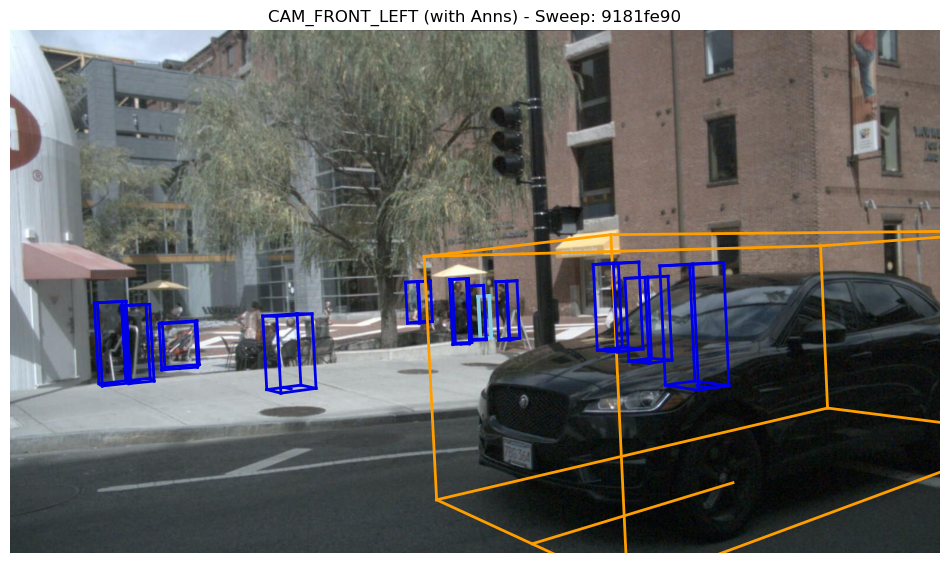

In [17]:
print(f"\n\n--- Camera View for Context (CAM_FRONT_LEFT) with Annotations ---")
if nusc and TARGET_LIDAR_SD_TOKEN:
    try:
        lidar_sweep_rec = nusc.get('sample_data', TARGET_LIDAR_SD_TOKEN)
        sample_token = lidar_sweep_rec['sample_token']
        sample_rec = nusc.get('sample', sample_token)

        cam_front_left_token = sample_rec['data'].get('CAM_FRONT_LEFT')

        if cam_front_left_token:
            print(f"  Displaying CAM_FRONT_LEFT image with annotations for sample_token: {sample_token}")
            
            # Use nusc.render_sample_data to show image with annotations
            # This function directly uses matplotlib to render.
            # Ensure your matplotlib backend is set up for inline display in notebooks (e.g., %matplotlib inline)
            
            # Create a new figure and axis for nusc.render_sample_data to draw on
            fig_cam_ann, ax_cam_ann = plt.subplots(1, 1, figsize=(12, 9)) # Adjust figsize as needed
            
            nusc.render_sample_data(
                cam_front_left_token,
                with_anns=True,
                verbose=False, # Set to True for more nusc output if needed
                ax=ax_cam_ann, # Pass the axis for drawing
                show_lidarseg=False, # Assuming you don't need lidar segmentation overlay here
                # filter_lidarseg_labels=None, # Not relevant if show_lidarseg is False
                # lidarseg_preds_bin_path=None # Not relevant
            )
            ax_cam_ann.set_title(f"CAM_FRONT_LEFT (with Anns) - Sweep: {TARGET_LIDAR_SD_TOKEN[:8]}")
            plt.show() # Explicitly show the plot

        else:
            print(f"  CAM_FRONT_LEFT data not found for sample_token: {sample_token}")
            
    except Exception as e:
        print(f"  Error displaying camera image with annotations: {e}")
        import traceback
        print(traceback.format_exc())

In [21]:
# In Cell 7, after you've created your 'enhanced_plot' or other k3d.Plot object
# And after the "Enhanced K3D Visualization" print block.

from src.data_utils.label_generation import find_instances_in_scene, get_interpolated_extrapolated_boxes_for_instance


print(f"\n\n--- Adding 3D GT Annotation Boxes to K3D Plot ---")

# Ensure necessary variables are available
if nusc and enhanced_plot and TARGET_LIDAR_SD_TOKEN and config:
    try:
        # Get scene_token from TARGET_LIDAR_SD_TOKEN
        lidar_sd_rec_for_scene = nusc.get('sample_data', TARGET_LIDAR_SD_TOKEN)
        sample_rec_for_scene = nusc.get('sample', lidar_sd_rec_for_scene['sample_token'])
        scene_token = sample_rec_for_scene['scene_token']
        
        # --- Logic adapted from visualize_sweep_k3d to draw GT boxes ---
        instance_tokens_in_scene = find_instances_in_scene(nusc, scene_token, min_annotations=1)
        
        all_scene_sweeps_list = list(get_scene_sweep_data_sequence(nusc, scene_token))
        
        current_sweep_idx_in_list = -1
        for idx, sdd_box_loop_var in enumerate(all_scene_sweeps_list):
            if sdd_box_loop_var['lidar_sd_token'] == TARGET_LIDAR_SD_TOKEN:
                current_sweep_idx_in_list = idx
                break
        
        if current_sweep_idx_in_list != -1 and instance_tokens_in_scene:
            print(f"  Found {len(instance_tokens_in_scene)} instances in scene '{nusc.get('scene', scene_token)['name']}'. Plotting their 3D boxes for the target sweep.")
            
            viz_cfg_for_boxes = config.get('visualization', {}).get('k3d_plot', {})
            color_map_instances = plt.cm.get_cmap(viz_cfg_for_boxes.get('instance_colormap', 'tab20'), 20)
            inst_color_idx = 0

            for inst_token in instance_tokens_in_scene:
                boxes_for_inst, _, _, _ = get_interpolated_extrapolated_boxes_for_instance(
                    nusc, inst_token, all_scene_sweeps_list
                )
                gt_box_at_sweep: Optional[NuScenesDataClassesBox] = boxes_for_inst[current_sweep_idx_in_list]
                
                if gt_box_at_sweep:
                    instance_color_rgb = color_map_instances(inst_color_idx % 20)[:3]
                    instance_color_hex = int(instance_color_rgb[0]*255)<<16 | int(instance_color_rgb[1]*255)<<8 | int(instance_color_rgb[2]*255)
                    inst_color_idx += 1
                    
                    corners = gt_box_at_sweep.corners() 
                    box_edges = [
                        (0, 1), (1, 2), (2, 3), (3, 0), 
                        (4, 5), (5, 6), (6, 7), (7, 4), 
                        (0, 4), (1, 5), (2, 6), (3, 7)
                    ]
                    
                    for start_idx, end_idx in box_edges:
                        segment_vertices = corners[:, [start_idx, end_idx]].T.astype(np.float32)
                        enhanced_plot += k3d.line(
                            segment_vertices, 
                            shader='simple', 
                            color=instance_color_hex,
                            width=viz_cfg_for_boxes.get('gt_box_line_width', 0.03),
                            name=f'GTBox3D_{inst_token[:6]}_{gt_box_at_sweep.name[:5]}'
                        )
            print(f"  Added 3D GT boxes to the K3D plot. Please re-check the plot.")
            
            # If your K3D plot doesn't auto-update, you might need to re-display it
            # or ensure the cell output mechanism handles updates.
            # Forcing a re-display if in a notebook:
            from IPython.display import display
            display(enhanced_plot)

        elif not instance_tokens_in_scene:
            print("  No instances with annotations found in this scene to plot 3D boxes for.")
        elif current_sweep_idx_in_list == -1:
            print("  Could not find the target sweep index in the scene's sweep list for 3D box plotting.")
            
    except Exception as e:
        print(f"  Error adding 3D GT boxes to K3D plot: {e}")
        import traceback
        print(traceback.format_exc())
else:
    missing_vars = []
    if not nusc: missing_vars.append("nusc")
    if not enhanced_plot: missing_vars.append("enhanced_plot (K3D plot object)")
    if not TARGET_LIDAR_SD_TOKEN: missing_vars.append("TARGET_LIDAR_SD_TOKEN")
    if not config: missing_vars.append("config")
    print(f"  Cannot add 3D GT boxes: Prerequisites not met. Missing: {', '.join(missing_vars)}.")



--- Adding 3D GT Annotation Boxes to K3D Plot ---
  Found 123 instances in scene 'scene-0103'. Plotting their 3D boxes for the target sweep.
  Added 3D GT boxes to the K3D plot. Please re-check the plot.


Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…